# **11 · P3 Data Preparation — 7개년을 한 패널로 합치되, 2022가 추세를 삼키지 않게**

### **"재코딩 경계는 의미 기반으로 못박고, 90,996행 결합 후 `wt_year_eq`로 2022 표본지배(64.8%)를 14.3%까지 균등화한다"**

> KPF 「언론 통계 분석·활용 경진대회」 · 분석 단위 = **연도(2019~2025) × 응답자** · 산출 = 반복횡단면 통합 패널(90,996행)

> 📍 **파이프라인 위치**: 5단계 표준 흐름 中 **② 데이터 전처리** · CRISP-DM **P3(Data Preparation)** · [전체 지도](README.md)

## **연구 질문 (이 노트북이 답하는 것)**

> **Q1.** 노트북 10의 crosswalk를 적용한 **재코딩이 원시 특수코드를 의미에 맞게** 정리하는가 — 소득·직업·신뢰 문항의 경계는 정확한가?
> **Q2.** 7개년을 결합할 때 **2022 대표본의 추세 지배**를 어떻게 제거하는가 — 어떤 가중치가 옳은가?
> **Q3.** 산출 패널은 **무결성**(총 N·구조적 결측·재현성)을 보장하는가?

→ 이 노트북은 새 분석을 하지 않는다. 노트북 10이 확정한 crosswalk·결측 원칙을 `src/harmonize.py`(SSOT)로 **실제 패널에 적용**하고, 단계별 전/후·자기점검으로 **입증**하는 P3 단계다.

## **목차**

| § | 내용 | 핵심 질문 |
|:--:|------|-----------|
| 1 | 단년 빌드 시연(전/후) | 원시 특수코드 → 정리 |
| 2 | 재코딩 단위검증 (+ DB①) | 경계 규칙 정확성 |
| 3 | 7개년 결합 + 가중치 (+ DB②) | 2022 지배 제거 |
| 4 | 자기점검 — 무결성 | 입증 |
| 5~6 | 산출·종합 | 재현·결론 |

> **thin 원칙**: 재코딩·결합·가중치 로직은 `src/harmonize.py`가 정본. 본 노트북은 그 **단계함수**(`build_year`·`recode_*`·`add_weight_normalization`·`presence_matrix`)를 호출해 *전/후·중간 산출*을 보여줄 뿐 로직을 재구현하지 않는다.
> - 입력: `data/raw/audience/*/*.sav`(7개년, **git 포함**) — 노트북 10 §3대로 2022는 개인용.
> - 산출: `data/processed/audience_harmonized.parquet`(**gitignore** → 본 노트북/`python src/harmonize.py`로 재생성).
> ✅ **검증 게이트 해소**(data-spec §6 → kpf-revalidation, 2026-07-11): 분석 수치는 원자료 재검증 **전 셀 일치**로 확정(입증 노트북 `12` · 자격등급 = p6-pdf-structure §3).
> **종합 문서**: [preprocessing-design.md](../docs/design/preprocessing-design.md) · [variable-crosswalk.md](../docs/design/variable-crosswalk.md) · [05-research-harmonization.md](../docs/groundwork/05-research-harmonization.md) §6


In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd

ROOT = Path.cwd()
while not (ROOT / "src" / "harmonize.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
import harmonize as hz

get_ipython().run_line_magic("matplotlib", "inline")  # 인라인 렌더 → PNG 출력 임베드
import matplotlib.pyplot as plt
from matplotlib import font_manager
def _kfont():
    for nm in ["Malgun Gothic", "맑은 고딕", "NanumGothic", "Gulim"]:
        try:
            font_manager.findfont(nm, fallback_to_default=False)
            plt.rcParams["font.family"] = nm; break
        except Exception: continue
    plt.rcParams["axes.unicode_minus"] = False
_kfont()
print("ROOT =", ROOT, "| 연도 =", hz.YEARS)

ROOT = C:\Users\kik32\workspace\Dacon\Media-Statistics-Analysis-and-Utilization-Competition\.claude\worktrees\media-stats-notebook-refactor-1a8b79 | 연도 = [2019, 2020, 2021, 2022, 2023, 2024, 2025]


## 1. 단년 빌드 시연 — 원시 → 재코딩(전/후)

한 연도(2025)에 `build_year`를 적용하기 전에, **원시 .sav가 어떤 특수코드를 담고 있는지**와 재코딩이 그것을 어떻게 정리하는지 본다. 예: 신뢰성 지표 `cred_fair`(2025=`Q85_1`)와 가구소득(`BQ5`).

In [2]:
raw25, meta25, enc25 = hz.read_sav_any(hz.SAV_BY_YEAR[2025])
print("2025 원시 shape =", raw25.shape, "enc =", enc25)

# (a) credibility 지표 원시 분포 — 1~5 외 특수코드 존재 확인
src_fair = hz.CRED_BATTERY["cred_fair"][2025]   # 'Q85_1'
print(f"\\n[원시 {src_fair}=cred_fair(2025)] value_counts(dropna=False):")
print(raw25[src_fair].value_counts(dropna=False).sort_index())
after = hz.recode_trust(raw25[src_fair])
print(f"→ recode_trust 후: 유효(1~5)={after.notna().sum():,}, NA={after.isna().sum():,} "
      f"(1~5 외는 전부 NA)")

2025 원시 shape = (6000, 223) enc = euc-kr
\n[원시 Q85_1=cred_fair(2025)] value_counts(dropna=False):
Q85_1
1.0      87
2.0    1193
3.0    2280
4.0    2281
5.0     159
Name: count, dtype: int64
→ recode_trust 후: 유효(1~5)=6,000, NA=0 (1~5 외는 전부 NA)


In [3]:
# (b) 가구소득 — 9밴드→7밴드 통일(특수코드/소득없음 처리)
src_inc = hz.SRC["income"][2025]  # 'BQ5'
b9, b7 = hz.recode_income(raw25[src_inc], 2025)
chk = pd.DataFrame({
    "원시": raw25[src_inc].value_counts(dropna=False).sort_index(),
    "band9": b9.value_counts(dropna=False).sort_index(),
    "band7": b7.value_counts(dropna=False).sort_index(),
})
chk

,원시,band9,band7
BQ5,,,
1.0,231,231,231.0
2.0,537,537,537.0
3.0,1054,1054,1054.0
4.0,1170,1170,1170.0
5.0,965,965,965.0
6.0,1011,1011,1011.0
7.0,573,573,1032.0
8.0,294,294,NaN
9.0,165,165,NaN


In [4]:
# (c) build_year 전체 — 표준 스키마 산출(가중치명 통일 WT, 연령 비닝키 birth_cohort 포함)
out25 = hz.build_year(2025)
print("표준 스키마 컬럼:", list(out25.columns))
out25.head()

OK 2025: N=6,000 enc=euc-kr wt=WT | trust_overall_valid=6,000 income9_valid=6,000 richness8_mean=2.14
표준 스키마 컬럼: ['year', 'resp_id', 'wt', 'sex', 'age', 'edu', 'income_band9', 'income_band7', 'job', 'region', 'trust_news_overall', 'trust_news_used', 'trust_society', 'cred_fair', 'cred_professional', 'cred_accurate', 'cred_trustworthy', 'press_free', 'media_influence', 'media_main_route_code', 'media_main_route', 'use_paper', 'use_magazine', 'use_tv', 'use_radio', 'use_internet', 'use_messenger', 'use_sns', 'use_video', 'use_short', 'use_ott', 'use_ai', 'richness_fixed8', 'richness_incl', 'birth_cohort']


,year,resp_id,wt,sex,age,edu,income_band9,income_band7,job,region,...,use_internet,use_messenger,use_sns,use_video,use_short,use_ott,use_ai,richness_fixed8,richness_incl,birth_cohort
0,2025,2025_0,1.256427,1.0,41.0,3.0,7.0,7,2.0,2.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,4.0,4.0,1984.0
1,2025,2025_1,0.725178,1.0,57.0,3.0,4.0,4,3.0,17.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,5.0,5.0,1968.0
2,2025,2025_2,0.351522,1.0,71.0,2.0,2.0,2,4.0,17.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1954.0
3,2025,2025_3,0.510234,2.0,47.0,2.0,2.0,2,4.0,17.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,1978.0
4,2025,2025_4,0.512560,1.0,39.0,3.0,4.0,4,6.0,17.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,3.0,1986.0


#### **[발견 ①] 재코딩은 원시 특수코드를 '의미 기반으로' 정리한다**

원시 신뢰성 문항은 1~5 응답 + (무응답/특수코드)을 담고 있고, `recode_trust`가 1~5만 남기고 나머지를 NA로 정리한다. 소득은 9밴드→7밴드로 통일돼 7개년 비교가 가능해진다. `build_year`는 가중치를 표준 `WT`(`wt`)로, 연령에서 `birth_cohort`(출생코호트)를 파생한다.

→ **① 단년 빌드 시연 — 완료(원시→표준 스키마 변환 확인). 다음은 그 경계가 *정확한지* 단위검증.**

## 2. 재코딩 단위검증 — 합성 입력으로 기대 출력 대조

`src/harmonize`의 순수 재코딩 함수에 **소표본 합성 입력**을 넣어 경계 동작을 assert로 못박는다(회귀 방지).

In [5]:
import numpy as np
# recode_trust: 1~5만 유효, 0·6·9999·NaN → NA
t = hz.recode_trust(pd.Series([1, 3, 5, 0, 6, 9999, np.nan]))
assert list(t.dropna()) == [1, 3, 5] and t.isna().sum() == 4

# recode_age: (0,120) 밖 → NA
a = hz.recode_age(pd.Series([19, 45, 80, 0, 999, -3]))
assert list(a.dropna()) == [19, 45, 80] and a.isna().sum() == 3

# recode_income(2022=7밴드): 7은 band7 유지·band9 NA / recode_income(2025=9밴드): 8,9→band7=7
b9_22, b7_22 = hz.recode_income(pd.Series([1, 6, 7, 10]), 2022)
assert list(b7_22.dropna()) == [1, 6, 7] and list(b9_22.dropna()) == [1, 6]   # 7→band9 NA, 10→NA
b9_25, b7_25 = hz.recode_income(pd.Series([1, 8, 9, 10]), 2025)
assert list(b9_25.dropna()) == [1, 8, 9] and list(b7_25.dropna()) == [1, 7, 7]  # 10=소득없음→NA

# recode_edu(2019=5단계→4단계): {1,2}→1(중졸이하)
e19 = hz.recode_edu(pd.Series([1, 2, 3, 4, 5]), 2019)
assert list(e19) == [1, 1, 2, 3, 4]

# recode_job: 9997=기타→13(실범주 보존, 결측 아님)
j = hz.recode_job(pd.Series([1, 13, 9997, 21]))
assert list(j.dropna()) == [1, 13, 13] and j.isna().sum() == 1   # 21=잔여코드→NA
print("PASS — recode_trust/age/income/edu/job 경계 동작 모두 기대와 일치.")

PASS — recode_trust/age/income/edu/job 경계 동작 모두 기대와 일치.


#### **[발견 ②] 결측은 '값'이 아니라 '의미'로 가른다 — 경계 2건이 핵심**

특히 두 경계가 중요하다 — ① **소득 10=소득없음→NA**(블랭킷 NA가 아니라 의미 기반), ② **직업 9997=기타→13**(실범주이므로 결측 처리 금지). 두 규칙은 `harmonize` docstring(§3)과 일치하며 코드리뷰 통과.

→ **② 재코딩 단위검증 — 완료(경계 동작 assert로 못박음, 회귀 방지).**

### **Decision Box ① — 특수코드 재코딩: 값 기반 일괄 ✗ → 의미 기반 분기**

**기준: 원시 특수코드(소득 10·직업 9997 등)를 결측으로 볼 것인가, 실범주로 볼 것인가.**

| 코드 | 값 기반(순진한) 처리 | 의미 | **채택 규칙** |
|------|------|------|------|
| 소득 `10`=소득없음 | "큰 값" → 상위 소득밴드? | *소득 부재* | **→ NA** (밴드 아님) |
| 직업 `9997`=기타 | 큰 수 → 결측? | *실재 범주(기타)* | **→ 13** (결측 금지) |
| 신뢰 무응답/특수 | 0 또는 평균대치? | 무응답 | **→ NA** (1~5만 보존) |

**왜 의미 기반인가**: "10이 9보다 크니 더 높은 소득"으로 처리하면 *소득 없음*이 최상위로 둔갑한다. 반대로 직업 9997(기타)을 결측 처리하면 실재 응답자를 버린다.
숫자의 크기가 아니라 **코드북이 부여한 의미**로 분기해야 한다. → `recode_*` 함수가 코드별로 명시 분기, §2 단위검증이 경계를 assert로 고정.


## 3. 7개년 결합 + 가중치 정규화 (2022 표본지배 보정)

전 연도 `build_year`를 누적해 단일 패널로 만들고, `add_weight_normalization`으로 `wt_year_eq`(연도기여 균등)·`wt_within`을 추가한다. `wt_year_eq`는 각 연도의 가중합을 `N/T`로 균등화해 **2022 대표본 지배를 제거**한다.

In [6]:
panel = pd.concat([hz.build_year(y) for y in hz.YEARS], ignore_index=True)
panel = hz.add_weight_normalization(panel)
panel = hz.add_year_dummies(panel)
print("\\n패널 shape =", panel.shape)
print("연도별 N:", {y: int((panel['year'] == y).sum()) for y in hz.YEARS})

OK 2019: N=5,040 enc=euc-kr wt=wt1 | trust_overall_valid=0 income9_valid=5,017 richness8_mean=2.23


OK 2020: N=5,010 enc=euc-kr wt=WT | trust_overall_valid=5,010 income9_valid=4,991 richness8_mean=2.28


OK 2021: N=5,010 enc=utf-8 wt=WT | trust_overall_valid=5,010 income9_valid=4,985 richness8_mean=2.30


OK 2022: N=58,936 enc=utf-8 wt=WT | trust_overall_valid=58,936 income9_valid=48,815 richness8_mean=2.06
OK 2023: N=5,000 enc=euc-kr wt=HMWT | trust_overall_valid=5,000 income9_valid=5,000 richness8_mean=2.17


OK 2024: N=6,000 enc=euc-kr wt=WT | trust_overall_valid=6,000 income9_valid=6,000 richness8_mean=2.04
OK 2025: N=6,000 enc=euc-kr wt=WT | trust_overall_valid=6,000 income9_valid=6,000 richness8_mean=2.14


\n패널 shape = (90996, 45)
연도별 N: {2019: 5040, 2020: 5010, 2021: 5010, 2022: 58936, 2023: 5000, 2024: 6000, 2025: 6000}


In [7]:
# 가중치 정규화 검증 — 연도별 합계(wt_year_eq는 전부 N/T로 균등해야)
wsum = panel.groupby("year")[["wt", "wt_within", "wt_year_eq"]].sum().round(1)
wsum["목표(N/T)"] = round(len(panel) / hz.T, 1)
wsum

,wt,wt_within,wt_year_eq,목표(N/T)
year,,,,
2019,5039.2,5040.0,12999.4,12999.4
2020,5010.0,5010.0,12999.4,12999.4
2021,5010.0,5010.0,12999.4,12999.4
2022,58936.0,58936.0,12999.4,12999.4
2023,5000.0,5000.0,12999.4,12999.4
2024,6000.0,6000.0,12999.4,12999.4
2025,6000.0,6000.0,12999.4,12999.4


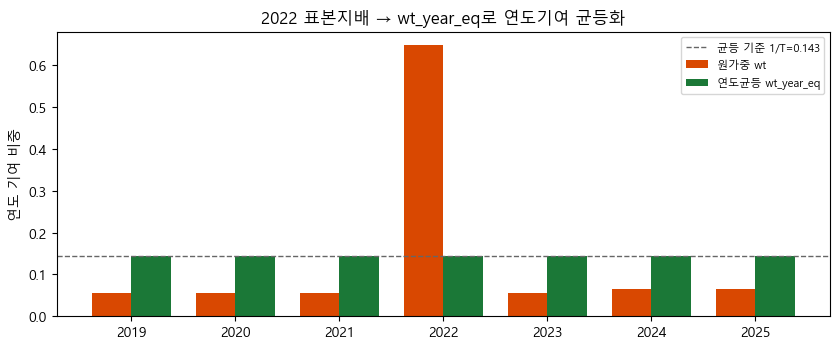

원가중에서 2022 비중 = 64.8% → wt_year_eq에서 = 14.3%


In [8]:
# 시각화: 연도 기여 비중 — 원가중(wt) vs 연도균등(wt_year_eq)
share_raw = panel.groupby("year")["wt"].sum(); share_raw = share_raw / share_raw.sum()
share_eq = panel.groupby("year")["wt_year_eq"].sum(); share_eq = share_eq / share_eq.sum()
fig, ax = plt.subplots(figsize=(8.5, 3.6))
x = np.arange(len(hz.YEARS)); w = 0.38
ax.bar(x - w/2, [share_raw[y] for y in hz.YEARS], w, label="원가중 wt", color="#d94801")
ax.bar(x + w/2, [share_eq[y] for y in hz.YEARS], w, label="연도균등 wt_year_eq", color="#1b7837")
ax.axhline(1/hz.T, ls="--", color="#666", lw=1, label=f"균등 기준 1/T={1/hz.T:.3f}")
ax.set_xticks(x); ax.set_xticklabels(hz.YEARS); ax.set_ylabel("연도 기여 비중")
ax.set_title("2022 표본지배 → wt_year_eq로 연도기여 균등화"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"원가중에서 2022 비중 = {share_raw[2022]:.1%} → wt_year_eq에서 = {share_eq[2022]:.1%}")

#### **[발견 ③] `wt_year_eq`가 2022 지배(64.8%)를 14.3%로 균등화한다**

원가중에서 2022가 전체의 **~64.8%**를 차지(표본지배)하지만, `wt_year_eq` 적용 후 모든 연도가 정확히 `1/T≈0.143`으로 균등해진다. 추세·평균은 전부 이 가중치를 사용해 2022 지배를 제거한다(05 §6 방법1).

→ **③ 7개년 결합·가중치 정규화 — 완료(2022 표본지배 제거, 연도기여 균등).**

### **Decision Box ② — 연도 통합 가중치: `wt_year_eq` 채택(2022 지배 제거)**

**기준: 7개년 통합 추세에서 각 연도가 동등한 무게로 들어가게 하는가.**

| 후보 | 정의 | 2022 기여 | 판정 |
|------|------|:--:|------|
| 비가중 | 단순 평균 | 표본수 비례(~65%) | 2022 지배 |
| `wt`(원가중) | 설문 설계가중만 | 여전히 ~64.8% | 2022 지배 |
| **`wt_year_eq`** | `(w/Σw)·(N/T)` — 연도 내 설계가중 보존 + 연도합을 N/T로 균등 | **1/7 ≈ 14.3%** | **채택** |

**왜 `wt_year_eq`인가**: 반복횡단면의 "연도 추세"는 각 연도가 *동등한 무게*로 들어가야 의미가 있다. 2022가 표본수만으로 추세를 끌고 가면
"2022의 특성 = 7개년 추세"라는 착시가 생긴다. `wt_year_eq`는 연도 내 설계가중은 보존하되 연도 간 기여를 균등화한다(05 §6 방법1).
→ 이후 EDA·추세·평균·구성비는 전부 이 가중치를 입력으로 받는다(노트북 20 DB①과 동일 원칙, 여기서 *생성*).
(검정 단계의 2022 과검정력은 가중이 아니라 *표본상한*으로 별도 통제 — 노트북 21.)


## 4. 자기점검 — 패널 무결성 (입증)

`src/harmonize.main()`이 콘솔로 출력하던 점검을 노트북에서 assert로 못박는다.

In [9]:
# (a) 총 N·연도별 N
assert len(panel) == 90996, f"총 N != 90,996 (={len(panel)})"
EXPECT_N = {2019: 5040, 2020: 5010, 2021: 5010, 2022: 58936, 2023: 5000, 2024: 6000, 2025: 6000}
for y in hz.YEARS:
    assert int((panel['year'] == y).sum()) == EXPECT_N[y], f"{y} N 불일치"

# (b) 핵심3지표 = 7개년 전부 유효응답 존재 / 단일문항 = 2020~2025만
for ind in hz.CRED_FACTOR_CORE3:
    by = panel.groupby("year")[ind].apply(lambda s: int(s.notna().sum()))
    assert all(by[y] > 0 for y in hz.YEARS), f"{ind} 일부 연도 결측"
ov = panel.groupby("year")["trust_news_overall"].apply(lambda s: int(s.notna().sum()))
assert ov[2019] == 0 and all(ov[y] > 0 for y in hz.YEARS if y >= 2020), "단일문항 가용연도 불일치"

# (c) wt_year_eq 연도합 균등
eq = panel.groupby("year")["wt_year_eq"].sum()
assert np.allclose(eq.values, len(panel)/hz.T, rtol=1e-6), "wt_year_eq 균등화 실패"
print("PASS — 총 N=90,996 · 연도별 N · 핵심3지표 7개년 · 단일문항 2020~ · 가중치 균등 모두 일치.")

PASS — 총 N=90,996 · 연도별 N · 핵심3지표 7개년 · 단일문항 2020~ · 가중치 균등 모두 일치.


In [10]:
# 연도×target 존재행렬(presence_matrix) — 구조적 결측 가시화
pm = hz.presence_matrix(panel)
pm

,N,sex,age,edu,income_band9,income_band7,job,region,trust_news_overall,trust_news_used,...,media_influence,use_paper,use_magazine,use_tv,use_radio,use_internet,use_messenger,use_sns,use_video,richness_fixed8
year,,,,,,,,,,,,,,,,,,,,,
2019,5040,5040,5040,5040,5017,5017,5040,5040,0,0,...,0,5040,164,4644,898,4267,3947,2476,2382,5040
2020,5010,5010,5010,5010,4991,4991,5010,5010,5010,0,...,0,5010,5010,5010,5010,5010,5010,5010,5010,5010
2021,5010,5010,5010,5010,4985,4985,5010,5010,5010,5010,...,5010,5010,5010,5010,5010,5010,5010,5010,5010,5010
2022,58936,58936,58936,58936,48815,58936,58936,58936,58936,58936,...,58936,58936,58936,58936,58936,58936,58936,58936,58936,58936
2023,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,...,5000,5000,141,5000,5000,4510,5000,5000,5000,5000
2024,6000,6000,6000,6000,6000,6000,6000,6000,6000,6000,...,6000,6000,282,6000,6000,5536,6000,6000,6000,6000
2025,6000,6000,6000,6000,6000,6000,6000,6000,6000,6000,...,6000,6000,267,6000,6000,5626,6000,6000,6000,6000


**[시각화] 구조적 결측 지도** — presence_matrix(연도×변수 유효응답 수)를 연도별 N으로 나눈 **유효응답 비율** 히트맵. 진한 칸=그 해 문항이 존재하고 응답도 충실, 흰 칸(0)=그 해 문항 자체가 부재. 결합 패널의 결측이 어디서 오는지(무응답이 아니라 설계)를 한 장으로 요약한다.

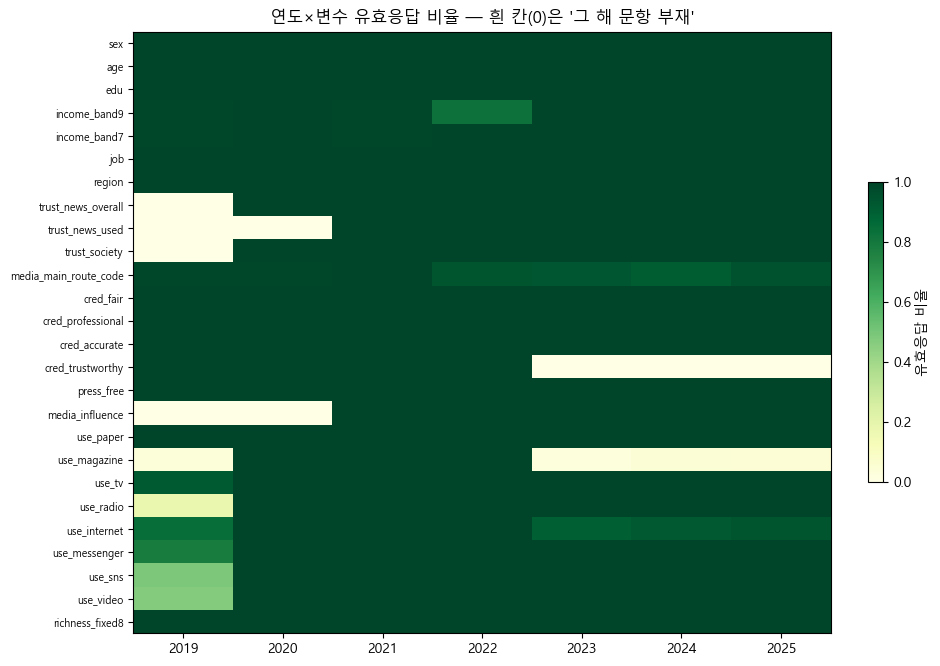

완전 부재(비율 0) 변수·연도: {'trust_news_overall': [2019], 'trust_news_used': [2019, 2020], 'trust_society': [2019], 'cred_trustworthy': [2023, 2024, 2025], 'media_influence': [2019, 2020]}


In [11]:
# [시각화] presence_matrix → 유효응답 비율 히트맵
prop = pm.drop(columns=["N"]).div(pm["N"], axis=0)      # 0~1
fig, ax = plt.subplots(figsize=(9.5, max(4.0, 0.26 * prop.shape[1])))
im = ax.imshow(prop.T.values, cmap="YlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(prop.index))); ax.set_xticklabels(prop.index)
ax.set_yticks(range(prop.shape[1])); ax.set_yticklabels(prop.columns, fontsize=7.5)
ax.set_title("연도×변수 유효응답 비율 — 흰 칸(0)은 '그 해 문항 부재'")
fig.colorbar(im, ax=ax, fraction=0.02, label="유효응답 비율")
fig.tight_layout(); plt.show()
zero = {c: [int(y) for y in prop.index[prop[c] == 0]]
        for c in prop.columns if (prop[c] == 0).any()}
print("완전 부재(비율 0) 변수·연도:", zero if zero else "없음")

## 5. 산출 — parquet 저장 & 재현 확인

`src/harmonize.py`와 동일 경로에 저장하고(`data/processed/`, gitignore), 라운드트립으로 동일성을 확인한다.

In [12]:
OUT = hz.OUT_PARQUET
OUT.parent.mkdir(parents=True, exist_ok=True)
panel.to_parquet(OUT, index=False)
reloaded = pd.read_parquet(OUT)
assert reloaded.shape == panel.shape
print(f"저장: {OUT.relative_to(ROOT)}  shape={reloaded.shape}")
print("재현 명령:  python src/harmonize.py   (동일 산출)")

저장: data\processed\audience_harmonized.parquet  shape=(90996, 45)
재현 명령:  python src/harmonize.py   (동일 산출)


## **6. 종합 — P3에서 무엇을 확정했나**

### **6-1. 연구 질문 답**
- **Q1(재코딩 정확성)**: 의미 기반 분기로 경계를 못박음 — 소득 10→NA, 직업 9997→실범주 보존, 신뢰 1~5만 보존. 합성 입력 단위검증 통과(§1·§2, DB①).
- **Q2(2022 지배 제거)**: `wt_year_eq=(w/Σw)·(N/T)`로 2022 기여를 64.8%→14.3%로 균등화. 연도 내 설계가중은 보존(§3, DB②).
- **Q3(무결성)**: 총 N=90,996·연도별 N·구조적 결측(presence_matrix)·parquet 라운드트립 동일성 전부 assert 통과(§4·§5).

### **6-2. 단계별 요약**

| § | 단계 | 입증 | 판정 |
|:--:|------|------|:--:|
| 1 | 단년 빌드(전/후) | 원시→표준 스키마 변환 | 통과 |
| 2 | 재코딩 단위검증 | 경계 2건 assert | 통과 |
| 3 | 결합+가중치 | 2022 64.8%→14.3% | 통과 |
| 4 | 무결성 자기점검 | N·결측·존재행렬 | 통과 |
| 5 | 산출·재현 | parquet 라운드트립 | 통과 |

### **6-3. `src/harmonize.py` 코드리뷰 결론**
- 인코딩 fallback(euc-kr→utf-8)이 2021·2022 utf-8에서 실제 동작(노트북 10 §1.1 입증), 라벨 한글 정상.
- 가중치명 4종 통일(`WEIGHT_BY_YEAR`), `wt_year_eq=(w/Σw)·(N/T)` 정규화 수식 정확(연도합=N/T 입증).
- 재코딩 경계(소득 10→NA, 직업 9997→13 실범주 보존, 학력 5→4단계) 의도대로 동작(§2 단위검증).
- 2022 분석단위=개인(개인용 N=58,936) 선택 타당(노트북 10 §3).
- → **결함 없음. 강제 수정 없이 리뷰 통과**(과잉수정 금지 원칙).

### **6-4. 다음 단계**
crosswalk가 적용된 무결 패널(90,996행)이 확정됐으므로, 이제 이 패널로 **7개년 통합 EDA**를 푼다 →
[`20-eda-overview.ipynb`](20-eda-overview.ipynb)(6패널) → 21·22(MGCFA·교차검증) → 23·24(정렬·APC) → 30(P5 종합).

> ✅ 본 노트북의 산출 수치는 *전처리 검증치*다. 원자료 재검증(노트북 `12`, 전 셀 일치) 완료로 확정 인용 자격은 p6-pdf-structure §3 표를 따른다.
